<a href="https://colab.research.google.com/github/jawadwali3454/AI-AND-ML/blob/main/Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Wholesale customers data.csv to Wholesale customers data.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline



In [6]:
df = pd.read_csv('Wholesale customers data.csv')
display(df.head())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [8]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


We selected a few customer samples to analyze their purchasing behavior before applying PCA. The samples show different spending patterns, which helps in understanding how PCA groups similar customers together after dimensionality reduction.

In [11]:
# Select three indices
indices = [22, 154, 398]

# Create DataFrame of chosen samples
samples = pd.DataFrame(df.loc[indices], columns=df.keys()).reset_index(drop=True)

print("Chosen samples of wholesale customers dataset:")

display(samples)

Chosen samples of wholesale customers dataset:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1,3,31276,1917,4469,9408,2381,4334
1,1,3,622,55,137,75,7,8
2,1,3,11442,1032,582,5390,74,247


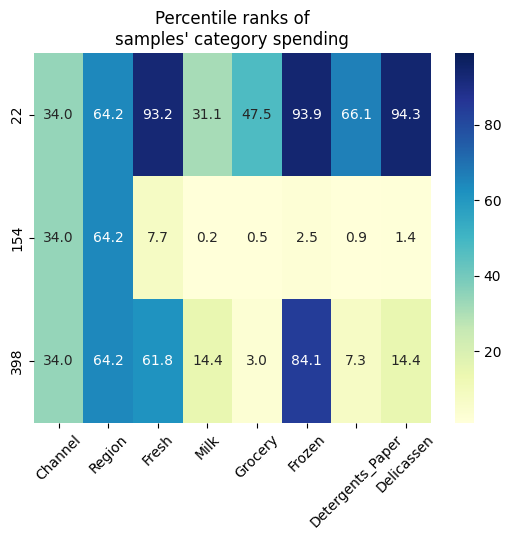

In [13]:
# look at percentile ranks
#pcts = 100. * data.rank(axis=0, pct=True).iloc[indices].round(decimals=3)
pcts = 100. * df.rank(axis=0, pct=True).iloc[indices].round(decimals=3)
# visualize percentiles with heatmap

sns.heatmap(pcts, annot=True, vmin=1, vmax=99, fmt='.1f', cmap='YlGnBu')
plt.title('Percentile ranks of\nsamples\' category spending')
plt.xticks(rotation=45, ha='center');


In [16]:
# Import libraries for Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# Remove column Milk
new_df = df.drop('Milk',axis=1)

In [18]:
# Split the data into training and testing sets(0.25) using the given feature as the target
# Set a random state.
X_train, X_test, y_train, y_test = train_test_split(new_df, df['Milk'], test_size=0.25, random_state=1)

# Create a decision tree regressor and fit it to the training set
regressor =  DecisionTreeRegressor(random_state=1)
regressor.fit(X_train, y_train)

# Report the score of the prediction using the testing set
score = regressor.score(X_test, y_test)
print(score)


0.3975791311651595


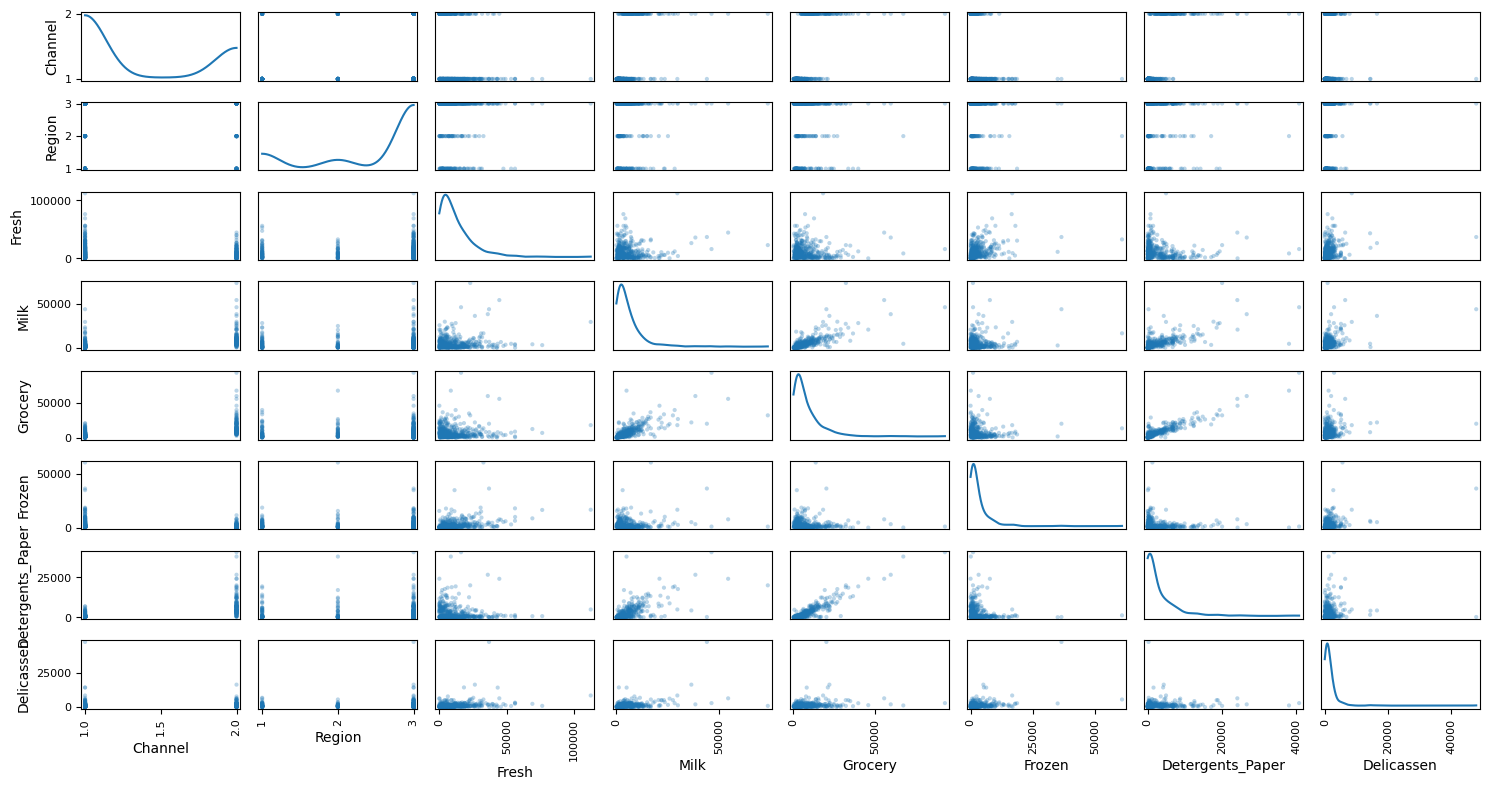

In [19]:
pd.plotting.scatter_matrix(df, alpha=0.3,figsize=(15,8),diagonal='kde' )
plt.tight_layout() # To avoid overlapping of plots

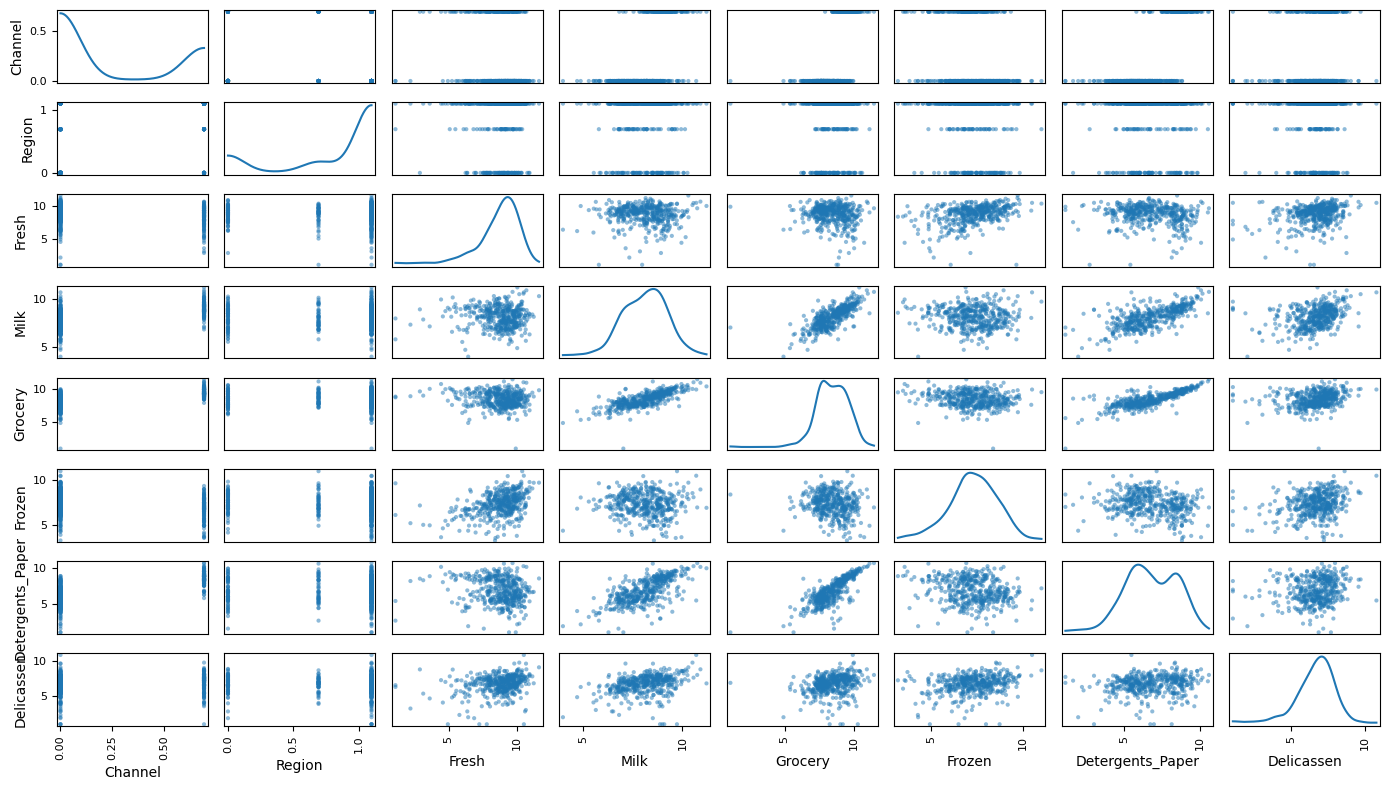

In [21]:
# Scale the data using the natural logarithm
log_data = np.log(df.copy())

# Scale the sample data using the natural logarithm
log_samples = np.log(samples)

# Produce a scatter matrix for each pair of newly-transformed features
pd.plotting.scatter_matrix(log_data, alpha=0.5, figsize=(14,8),diagonal='kde')
plt.tight_layout()

In [22]:
# Let's compare the original sample data to the log-transformed sample data
print("Original chosen samples of wholesale customers dataset:")
display(samples)

# Display the log-transformed sample data
print("Log-transformed samples of wholesale customers dataset:")
display(log_samples)

Original chosen samples of wholesale customers dataset:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1,3,31276,1917,4469,9408,2381,4334
1,1,3,622,55,137,75,7,8
2,1,3,11442,1032,582,5390,74,247


Log-transformed samples of wholesale customers dataset:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.0,1.098612,10.350606,7.558517,8.404920,9.149316,7.775276,8.374246
1,0.0,1.098612,6.432940,4.007333,4.919981,4.317488,1.945910,2.079442
2,0.0,1.098612,9.345046,6.939254,6.366470,8.592301,4.304065,5.509388


In [24]:
# For each feature find the data points with extreme high or low values
for feature in log_data.keys():

    # Calculate Q1 (25th percentile of the data) for the given feature
    Q1 = np.percentile(log_data, 25)

    # Calculate Q3 (75th percentile of the data) for the given feature
    Q3 = np.percentile(log_data, 75)

    # Use the interquartile range to calculate an outlier step (1.5 times the interquartile range)
    step = (Q3 - Q1) * 1.5

# Display the outliers
    print("Data points considered outliers for the feature '{}':".format(feature))
    display(log_data[~((log_data[feature] >= Q1 - step) & (log_data[feature] <= Q3 + step))])

    # Select the indices for data points you wish to remove
outliers  = [66, 75, 338, 142, 154, 289]

# Remove the outliers, if any were specified
good_data = log_data.drop(log_data.index[outliers]).reset_index(drop = True)

Data points considered outliers for the feature 'Channel':


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen


Data points considered outliers for the feature 'Region':


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen


Data points considered outliers for the feature 'Fresh':


...

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen


Data points considered outliers for the feature 'Detergents_Paper':


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen


Data points considered outliers for the feature 'Delicassen':


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen


In [28]:
from sklearn.decomposition import PCA

# Apply PCA by fitting the good data with the same number of dimensions as features
pca = PCA(n_components=6)
pca.fit(good_data)

# Transform log_samples using the PCA fit above
pca_samples = pca.transform(log_samples)


In [29]:
print(pca.components_)

[[ 1.16323557e-01  8.19434813e-03 -2.11359923e-01  3.91946401e-01
   4.37295284e-01 -2.05231531e-01  7.37216195e-01  1.06168822e-01]
 [ 4.78569503e-03 -4.28453188e-03  6.44088120e-01  1.85199449e-01
   1.11833896e-01  5.10252001e-01  8.63004357e-02  5.20094902e-01]
 [-2.22813792e-02 -1.08174213e-02 -6.28915224e-01  6.57390079e-02
  -3.60052745e-02  8.99930714e-02 -2.68849471e-01  7.19621690e-01]
 [-7.54887270e-04 -4.03980500e-02 -3.80048901e-01  1.32387933e-02
   6.12145916e-03  8.27899149e-01  1.65476223e-01 -3.75390651e-01]
 [-1.53084607e-02  1.79097421e-02  1.08622965e-02  7.43741474e-01
   3.07525983e-01 -1.08541754e-02 -5.40410789e-01 -2.43806598e-01]
 [ 3.06226293e-02 -1.98217334e-01  1.81116440e-04 -4.90978400e-01
   8.18718600e-01  3.49372080e-02 -2.17230425e-01 -1.58381803e-03]]


In [27]:
print(pca.explained_variance_)

[4.58738954 2.78078876 1.13750117 1.01831754 0.46756948 0.19901346]


In [30]:
pca_samples

array([[-0.12512987,  2.79996624,  0.07816734,  0.43400699, -1.36624917,
         0.03908966],
       [-6.18708469, -7.01318986, -0.96341491, -0.7473111 , -0.38426329,
         0.03622498],
       [-3.79559124, -0.26414102, -0.43524347,  0.83537823,  0.11577745,
        -0.58683488]])